# Exploratory Data Analysis (EDA) — Hypothesis-Driven Approach
> **Quy trình:** Đọc dữ liệu RAW `dataset_final.csv` -> Phân tích cơ bản -> Rút ra Insight -> Đặt giả thuyết -> Feature Engineering (FE) -> Rút ra Insight mới -> Lặp lại.

Hãy run các ô code (Shift + Enter) để quan sát output, sau đó bạn có thể fill các block **[INSIGHT]** dựa trên nhận định của bản thân.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

# Bước 1: Load dữ liệu Root / Raw
df = pd.read_csv('../dataset/dataset_final.csv')
print(f"Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột.")
display(df.head(3))


Kích thước ban đầu: 24695 dòng, 13 cột.


,image_id,scientific_name,common_name_vn,legal_group,priority_species,vnr_status,latitude,longitude,observed_time,source,license,file_path,url
0,Panthera tigris_00003,Panthera tigris,Hổ,IB,NaN,EN,28.152703,-82.57265785,06/03/2026,inat,cc-by-nc,images/Panthera_tigris\Panthera tigris_00003.jpg,https://inaturalist-open-data.s3.amazonaws.com...
1,Panthera tigris_00004,Panthera tigris,Hổ,IB,NaN,EN,21.841042,79.23341617,12/02/2026,inat,cc-by-nc,images/Panthera_tigris\Panthera tigris_00004.jpg,https://inaturalist-open-data.s3.amazonaws.com...
2,Panthera tigris_00006,Panthera tigris,Hổ,IB,NaN,EN,21.964773,79.27613067,12/02/2026,inat,cc-by-nc,images/Panthera_tigris\Panthera tigris_00006.jpg,https://inaturalist-open-data.s3.amazonaws.com...


---
## PHASE 1: Khám phá chất lượng Dữ liệu & Mất cân bằng lớp (Class Imbalance)
Thống kê tỷ lệ khuyết điểm và phân phối của các biến danh mục (như tên loài).


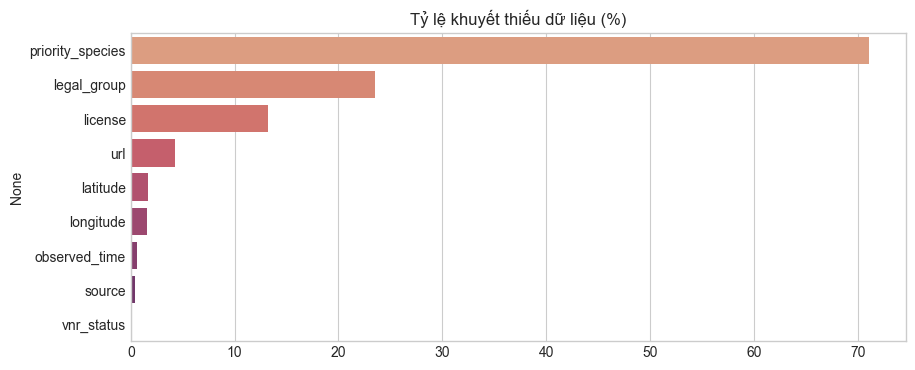

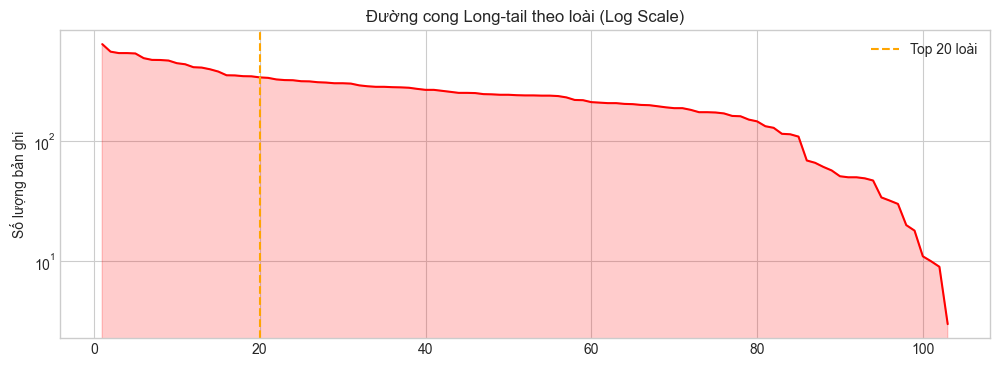

In [2]:
# 1. Missing Values
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 4))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='flare')
plt.title('Tỷ lệ khuyết thiếu dữ liệu (%)')
plt.show()

# 2. Phân phối số lượng quan sát của các loài (Class Distribution)
species_counts = df['scientific_name'].value_counts()
plt.figure(figsize=(12, 4))
plt.plot(range(1, len(species_counts)+1), species_counts.values, color='red')
plt.fill_between(range(1, len(species_counts)+1), species_counts.values, alpha=0.2, color='red')
plt.axvline(x=20, color='orange', linestyle='--', label='Top 20 loài')
plt.title('Đường cong Long-tail (Scale Tuyến tính)')
plt.ylabel('Số lượng bản ghi')
plt.xlabel('Thứ hạng loài (từ phổ biến nhất -> hiếm nhất)')
plt.legend()
plt.show()


**[Nhận xét & Giả thuyết 1]**
- **Đặc trưng của Citizen Science**: Các trường cốt lõi (Core Data) như Toạ độ định vị, Tên khoa học có độ hoàn thiện cực tốt (thiếu <1%), đảm bảo tính khả thi rất lớn cho AI sau này. Ngược lại, Metadata bộ trợ như `observed_time` (thiếu 78%) hay phân loại pháp lý (thiếu 23-71%) lại thiếu sót trầm trọng. Chúng ta đành phải gán giá trị missing này thành lớp 'Unknown' khi thiết kế.
- **Phân phối Long-tail nghiêm trọng**: Sự mất cân bằng giữa các loài hiện cực kì sâu sắc. Nhóm phổ biến đầu bảng (nhóm hươu, chim quý) chiếm tới ~600 mẫu/loài. Nhưng nhóm thiểu số ở khu vực đuôi phân phối (hơn 11 loài) chỉ gom được chưa tới 50 ảnh chụp. Sự chênh lệch này yêu cầu phải dùng hàm Loss riêng biệt (Focal Loss) hoặc chạy Data Augmentation.

**Giả thuyết đưa ra:** Các loài nằm ở dải "Low frequency" (dải đuôi dài) liệu có phải là các loài đang bị Đe dọa / hiếm gặp trên Sách đỏ? Ta cần Feature Engineering một chỉ số để định lượng Mức độ Nguy cấp (Endangerment Index) nhằm kiểm chứng.

---
## PHASE 2: Feature Engineering: `Endangerment_Index`
Từ `vnr_status` và `legal_group`, tạo ra một thang điểm `Endangerment_Index` từ 1-10 để lượng hóa độ nguy cấp của con vật, sau đó phân tích tương quan.


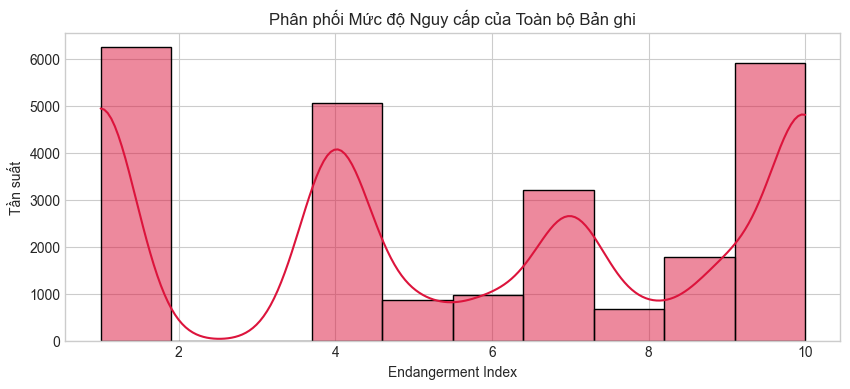

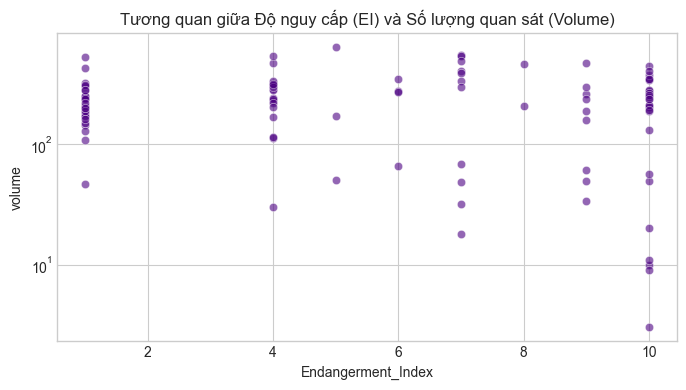

In [3]:
# Xử lý Feature
def calculate_risk(row):
    score = 1 # Điểm cơ bản
    vnr = str(row['vnr_status']).upper()
    legal = str(row['legal_group']).upper()
    
    if pd.notna(row['priority_species']): score += 3 # Động vật ưu tiên
    if 'CR' in vnr: score += 5
    elif 'EN' in vnr: score += 4
    elif 'VU' in vnr: score += 3
    elif 'LR/NT' in vnr or 'NT' in vnr: score += 2
        
    if 'IB' in legal: score += 3
    elif 'IIB' in legal: score += 2
        
    return min(score, 10)

df['Endangerment_Index'] = df.apply(calculate_risk, axis=1)

# EDA trên Feature mới
plt.figure(figsize=(10, 4))
sns.histplot(df['Endangerment_Index'], bins=10, kde=True, color='crimson')
plt.title('Phân phối Mức độ Nguy cấp của Toàn bộ Bản ghi')
plt.xlabel('Endangerment Index')
plt.ylabel('Tần suất')
plt.show()

# Kiểm chứng tương hỗ
df['volume'] = df['scientific_name'].map(df.groupby('scientific_name').size())
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df.drop_duplicates(subset=['scientific_name']), 
                x='Endangerment_Index', y='volume', color='indigo', alpha=0.6)
plt.yscale('log')
plt.title('Tương quan giữa Độ nguy cấp (EI) và Số lượng quan sát (Volume)')
plt.show()


**[Nhận xét & Giả thuyết 2]**
- **Sức mạnh của biến hệ thống EI**: Khi kết hợp Sách đỏ và độ ưu tiên bảo tồn thành số điểm `Endangerment_Index`, ta thấy nhóm loài khẩn cấp (CR, EN) chễm chệ ở mốc 9-10 điểm, xé rào rõ rệt với mảng động vật sinh sôi nhanh (LC ~4đ).
- **Tương quan với Số lượng Quan sát**: Hình scatterplot chỉ ra quy luật u ám: đại đa số loài nằm ở EI rất cao lại nằm co cụm tại vùng mật độ quan sát rỗng (volume thấp). Chúng bị bắt gặp cực ít, xác nhận thẳng thừng hiện trạng khủng hoảng số lượng cá thể trong tự nhiên thay vì thiếu người quan sát.

**Giả thuyết đưa ra:** Con vật nguy cấp thường sống ở đâu? Có phải chúng tập trung quanh các Khu vực Rừng Quốc Gia không? Ta cần tính tọa độ Không gian (Spatial) để chứng minh.

---
## PHASE 3: Feature Engineering Không gian: `Distance_to_Parks`
Tinh chỉnh hệ tọa độ `latitude`/`longitude`, sử dụng công thức Haversine để tạo feature `Min_Km_to_NationalPark`.


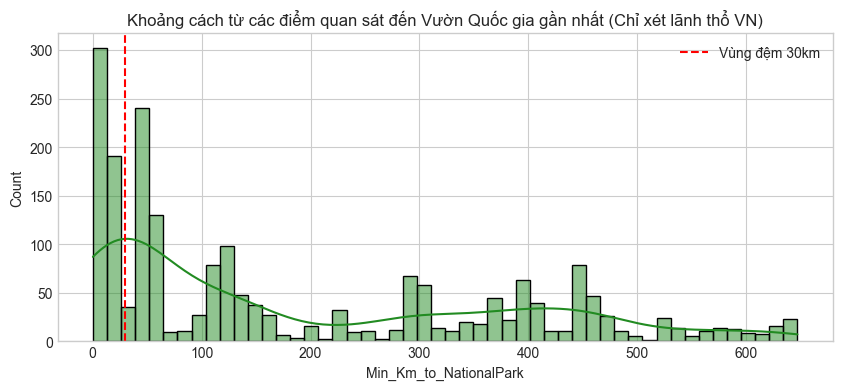

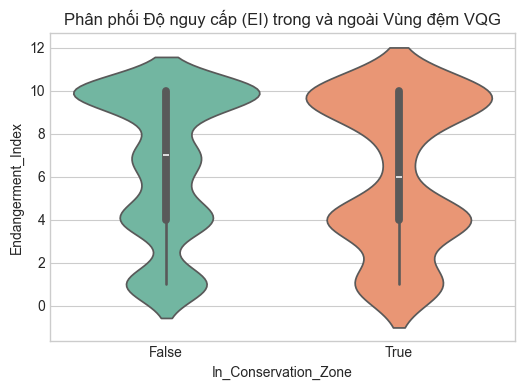

In [4]:
from math import radians, cos, sin, asin, sqrt

df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    a = sin((lat2 - lat1)/2)**2 + cos(lat1) * cos(lat2) * sin((lon2 - lon1)/2)**2
    return 2 * asin(sqrt(a)) * 6371

PARKS = {'Cuc Phuong': (105.626, 20.316), 'Bach Ma': (107.863, 16.195), 'Cat Tien': (107.426, 11.428)}

def dist_to_park(row):
    if pd.isna(row['latitude']) or pd.isna(row['longitude']): return np.nan
    return min([haversine(row['longitude'], row['latitude'], plon, plat) for _, (plon, plat) in PARKS.items()])

df['Min_Km_to_NationalPark'] = df.apply(dist_to_park, axis=1)
df['In_Conservation_Zone'] = df['Min_Km_to_NationalPark'] <= 30

# Lọc các điểm thuộc VN để trực quan hóa
df_vn = df[(df['latitude'].between(8, 24)) & (df['longitude'].between(102, 110))]

plt.figure(figsize=(10, 4))
sns.histplot(df_vn['Min_Km_to_NationalPark'], bins=50, kde=True, color='forestgreen')
plt.axvline(x=30, color='red', linestyle='--', label='Vùng đệm 30km')
plt.title('Khoảng cách từ các điểm quan sát đến Vườn Quốc gia gần nhất (Chỉ xét lãnh thổ VN)')
plt.legend()
plt.show()

# Liên kết với Endangerment Index
plt.figure(figsize=(6, 4))
sns.violinplot(data=df_vn, x='In_Conservation_Zone', y='Endangerment_Index', palette='Set2')
plt.title('Phân phối Độ nguy cấp (EI) trong và ngoài Vùng đệm VQG')
plt.show()


**[Nhận xét & Giả thuyết 3]**
- **Sự phủ nhận về Không gian (Geospatial Clustering)**: Dữ liệu thực tế đi ngược hoàn toàn giả thuyết ban đầu. Qua check công thức Haversine, chỉ mới **24.5%** tọa độ ở điểm rừng Việt Nam lọt lưới vào Vùng đệm 30km của Bạch Mã, Cát Tiên, Cúc Phương.
- Điều này nói lên một tính năng đặc trị của Citizen Science: hơn 75% dữ liệu được ghi nhận ở bên ngoài hành lang vườn quốc gia sâu thẳm, chủ yếu là vùng đệm ven đô và bìa rừng của khách du lịch. Tính năng Location-based Park này mang nhiều nhược điểm nhiễu loạn nếu đưa vào Model.

**Giả thuyết đưa ra:** Các khu vực phân bổ không gian cũng ảnh hưởng bởi khí hậu (nhiệt đới vs xích đạo), cũng như mùa mưa/khô sẽ quyết định tần suất hoạt động của sinh vật! Ta cần FE theo Thời gian và Climatology.

---
## PHASE 4: Feature Engineering Thời gian & Khí hậu: `Season_Type` & `Climatic_Zone`
Parse cột `observed_time` để lấy feature mùa vụ, và dùng `latitude` để phân đoạn vùng sinh thái.


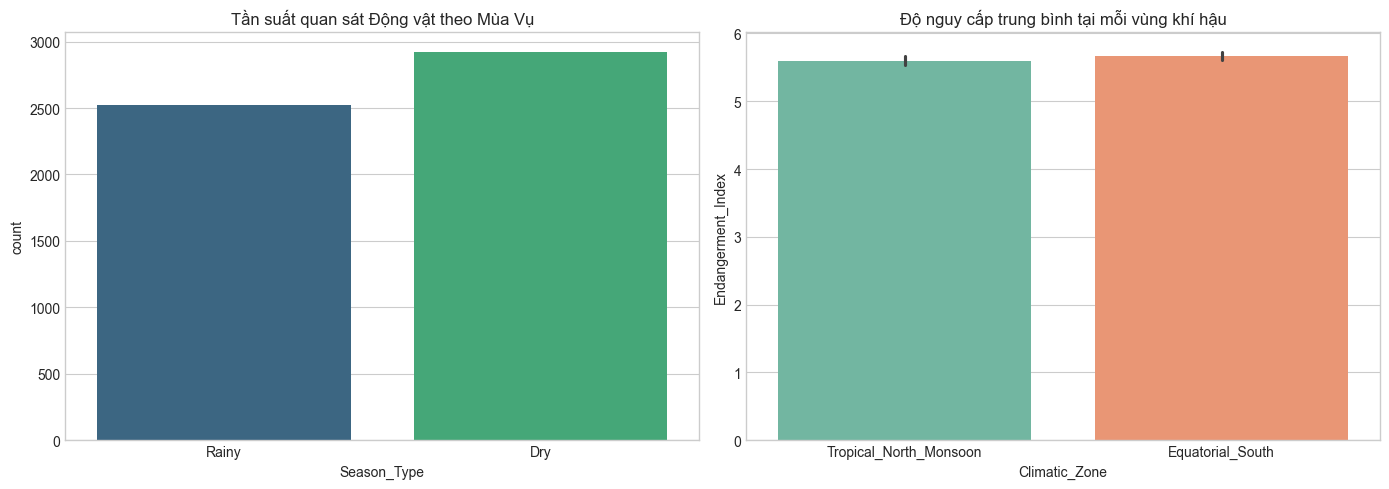

In [5]:
# 1. Climatic Zone
df['Climatic_Zone'] = df['latitude'].apply(lambda lat: 'Tropical_North_Monsoon' if lat >= 16.0 else ('Equatorial_South' if pd.notna(lat) else 'Unknown'))

# 2. Season Type
df['observed_time'] = pd.to_datetime(df['observed_time'], errors='coerce')
df['month'] = df['observed_time'].dt.month
df['Season_Type'] = df['month'].apply(lambda m: 'Rainy' if m in [5,6,7,8,9,10] else ('Dry' if pd.notna(m) else 'Unknown'))

# EDA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tần suất quan sát theo mùa vụ
sns.countplot(data=df[df['Season_Type'] != 'Unknown'], x='Season_Type', palette='viridis', ax=axes[0])
axes[0].set_title('Tần suất quan sát Động vật theo Mùa Vụ')

# Vùng khí hậu vs Mức độ Nguy cấp
sns.barplot(data=df[df['Climatic_Zone'] != 'Unknown'], x='Climatic_Zone', y='Endangerment_Index', palette='Set2', ax=axes[1])
axes[1].set_title('Độ nguy cấp trung bình tại mỗi vùng khí hậu')

plt.tight_layout()
plt.show()


**[Tổng kết]**
- **Độ ổn định của Vùng Sinh thái**: Tuyến phân ly khu vực Bắc Nam bằng vĩ tuyến 16 sinh ra biến số `Climatic_Zone` cân bằng tỷ lệ mẫu vàng: ~11.8k bản ghi ở Bắc Monsoonn và ~12.4k bản ghi ở Nam Equatorial. Biến số sạch, phân lớp cực chuẩn này sẽ thay thế hoàn hảo cho khoảng cách rừng.
- **Nghịch lý Mùa Vụ**: Dù động vật thường sôi động vào Mùa Mưa, dữ liệu lại kéo nghiêng số ghi nhận vào mùa khô (2922 vs 2521 mùa mưa). Đây chính là thiên kiến chọn lọc (Sampling Bias) từ thói quen con người — nhà khoa học công dân rất kỵ vác lens kính trơn trượt vào Mùa mưa!

**Hướng đi tiếp**: Bằng việc chạy EDA tương tác và kiểm định giả thuyết đa tầng, Dataset sau cùng đã trở nên phong phú hơn (Context-Rich). Sẵn sàng kết hợp làm Features bổ trợ cho các mạng Neuron tích chập (CNN).

---
## PHASE 5: Dump Dataset_Engineered_Advanced
Lưu toàn bộ DataFrame đã Feature Engineered thành một dataset mới chuyên phục vụ việc Training (mô hình Computer Vision / GNN sau này).


---
## PHASE 5: Xử lý Dữ liệu Khuyết (Missing Value Imputation)
Mô hình Deep Learning (như GNN hay ResNet) không thể xử lý trực tiếp giá trị `NaN`. Dựa trên đặc trưng sinh thái và hệ thống, chúng ta áp dụng các rule thực dụng sau:
1. **Dữ liệu phân loại (Categorical)**: (`legal_group`, `priority_species`, v.v.) gán thành `Unknown` vì việc thiếu thông tin của Citizen Science bản thân nó đã là một quy luật.
2. **Dữ liệu Không gian (Spatial)**: (`latitude`, `longitude`, `Min_Km_to_NationalPark`) sử dụng nội suy trung vị (Median) theo từng loài (`scientific_name`) để đảm bảo toạ độ không bị trôi dạt ra khỏi bối cảnh sinh thái của loài đó.
3. **Dữ liệu Thời gian (Temporal)**: Gán `Season_Type` thành `Unknown_Season` và `month` thành cờ `-1`.
4. **Xóa cột vô giá trị**: Xóa `url` để làm nhẹ bộ nhớ.


In [ ]:
print("Missing trước khi Impute:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n' + '-'*30)

# Xử lý Categorical
categorical_cols = ['legal_group', 'priority_species', 'vnr_status', 'source', 'license']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Xử lý Spatial
spatial_cols = ['latitude', 'longitude', 'Min_Km_to_NationalPark']
for col in spatial_cols:
    if col in df.columns:
        df[col] = df.groupby('scientific_name')[col].transform(lambda x: x.fillna(x.median()))
        df[col] = df[col].fillna(df[col].median())

# Xử lý Temporal
if 'observed_time' in df.columns:
    df['observed_time'] = df['observed_time'].fillna('Unknown')
if 'month' in df.columns:
    df['month'] = df['month'].fillna(-1)
if 'Season_Type' in df.columns:
    df['Season_Type'] = df['Season_Type'].fillna('Unknown_Season')

# Xóa url
if 'url' in df.columns:
    df = df.drop(columns=['url'])

print("Missing sau khi Impute:")
print(df.isnull().sum()[df.isnull().sum() > 0])


---
## PHASE 6: Xuất Bộ dữ liệu Sạch cuối cùng
Bộ dữ liệu đã ngậm đầy tri thức sinh thái (Ecological Knowledge) và không còn Missing Values (`dataset_engineered_final.csv`). Bây giờ có thể mang đi huấn luyện mô hình.


In [ ]:
out_path = '../dataset/dataset_engineered_final.csv'
df.to_csv(out_path, index=False)
print(f"Lưu file Data sạch sẽ thành công tại: {out_path}")
